In [ ]:
#predict the salary of employee while yeasof expirience is given 
!pip install scikit-learn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load the data
df = pd.read_csv("Salary_Data.csv")
df.head(2)

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205


In [3]:
#EDA exploratory data analysis
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  33 non-null     float64
 1   Salary           33 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 660.0 bytes


In [4]:
#get the sttistical info from data
df.describe()

,YearsExperience,Salary
count,33.000000,33.000000
mean,5.921212,82760.303030
std,3.342413,34014.620992
min,1.100000,37731.000000
25%,3.200000,56957.000000
50%,5.100000,67938.000000
75%,8.700000,109431.000000
max,13.000000,156000.000000


In [5]:
#check the missing values 
df.isna().sum()

YearsExperience    0
Salary             0
dtype: int64

C:\Users\Hp\AppData\Local\Temp\ipykernel_7152\2129282473.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


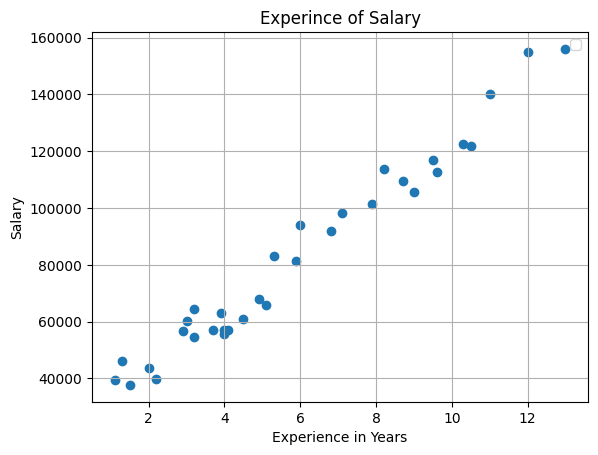

In [6]:
#visualiztion between x and y
plt.scatter(df['YearsExperience'],df['Salary']) 
plt.xlabel('Experience in Years')
plt.ylabel('Salary')
plt.title('Experince of Salary')
plt.legend()
plt.grid()

In [7]:
#conclusion
#from visualiztion their is linear relationships between x and y
#correlation analysis
df.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.983642
Salary,0.983642,1.000000


In [8]:
#split the data x and  y
# x-> it is mandatory that x must be 2D array Dataframe
# drop will remove the entity
# axis = 0 remove the row with the index
# axis = 1 remove the cloumn with name 
x = df.drop('Salary',axis =1).copy()

# it is mandatory the y becomes 1D array or object of Series
y = df['Salary']
print(x.shape,y.shape)

(33, 1) (33,)


In [12]:
## Train the model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
# train the model using x and y
model.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


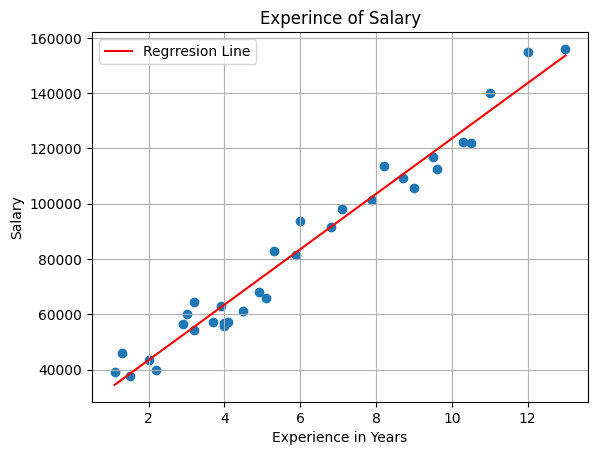

In [18]:
## result visualization 
plt.scatter(df['YearsExperience'],df['Salary']) 
#predict salaries 
y_pred = model.predict(x)
plt.plot(df['YearsExperience'],y_pred,color = "red",label = "Regrresion Line")

#regrresion line 
plt.xlabel('Experience in Years')

plt.ylabel('Salary')
plt.title('Experince of Salary')
plt.legend()
plt.grid()

In [19]:
## interpret the model
# get the coefficients 
model.coef_

array([10010.1995026])

In [21]:
model.intercept_

np.float64(23487.78839975789)

In [22]:
# so the required equation is 
# y = 10010.1995026 * x + 23487.78839

In [23]:
# MODEL INFERENCE 
model.predict([[15]])

C:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  Returns


array([173640.78093875])

In [25]:
y = 10010.1995026 * 15 + 23487.78839
y

173640.780929